# Graph Neural Network 

In [1]:
# pip install torch torch-geometric

In [2]:
import pandas as pd
import glob
import os
import numpy as np
from scipy.sparse import lil_matrix
import torch

### Import the data

In [3]:
node_features = pd.read_csv('../data/tarca-et-al-2021/GNN/protein_metadata.csv')
node_features

,target,mean_log2rfu_Second_Control,mean_log2rfu_Second_PPROM,mean_log2rfu_Second_sPTD,mean_log2rfu_Third_Control,mean_log2rfu_Third_PPROM,mean_log2rfu_Third_sPTD,median_log2rfu_Second_Control,median_log2rfu_Second_PPROM,median_log2rfu_Second_sPTD,...,iqr_25_Second_sPTD,iqr_25_Third_Control,iqr_25_Third_PPROM,iqr_25_Third_sPTD,iqr_75_Second_Control,iqr_75_Second_PPROM,iqr_75_Second_sPTD,iqr_75_Third_Control,iqr_75_Third_PPROM,iqr_75_Third_sPTD
0,14-3-3,0.826509,0.837844,0.836105,0.843146,0.870307,0.859885,0.827322,0.837483,0.837771,...,0.827716,0.834492,0.865852,0.851804,0.834041,0.841370,0.845026,0.851797,0.876493,0.868789
1,17-beta-HSD 1,1.039331,1.034167,1.045755,1.047494,1.037818,1.048190,1.038866,1.034165,1.045173,...,1.042967,1.043001,1.035651,1.045397,1.042211,1.035112,1.046881,1.049907,1.040611,1.050091
2,3HIDH,1.025016,1.054714,1.021769,1.023033,1.034687,1.013683,1.022154,1.052699,1.020257,...,1.018559,1.017164,1.030238,1.008887,1.026666,1.056137,1.023638,1.024794,1.035545,1.016286
3,4-1BB,1.012235,0.983925,0.998452,1.010340,0.975572,0.991096,1.011176,0.984028,0.998080,...,0.996342,1.007088,0.974744,0.989074,1.014947,0.984835,0.999465,1.012825,0.977223,0.992481
4,4-1BB ligand,1.038029,1.023171,1.031025,1.036747,1.011234,1.029969,1.034936,1.023076,1.030416,...,1.029106,1.030214,1.010650,1.027399,1.040097,1.023557,1.031865,1.038182,1.012037,1.030997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,tPA,0.969760,0.954907,0.963234,0.970428,0.988567,0.957223,0.970400,0.954608,0.963387,...,0.961644,0.965357,0.986691,0.955165,0.974941,0.955729,0.964460,0.975861,0.991526,0.958863
1161,tau,1.050778,1.047259,1.049910,1.043601,1.058016,1.043847,1.050501,1.047388,1.048849,...,1.047770,1.038230,1.056058,1.041123,1.058667,1.048691,1.051005,1.050278,1.059209,1.045619
1162,"transcription factor MLR1, isoform CRA_b",1.003100,0.997091,1.001045,1.005490,0.995674,0.998041,1.002672,0.997238,1.000437,...,0.999875,1.003176,0.993928,0.996882,1.005024,0.997941,1.001775,1.006988,0.997005,0.999369
1163,uPA,1.021040,1.018464,1.015970,1.017589,0.995355,0.996281,1.020216,1.018656,1.015881,...,1.013144,1.012496,0.994205,0.993109,1.024350,1.020953,1.017573,1.022258,0.997082,0.998618


In [4]:
# Weighted edges
string_interactions = pd.read_csv("../data/tarca-et-al-2021/string_interactions.tsv", delimiter = "\t")
string_interactions

,#node1,node2,node1_string_id,node2_string_id,neighborhood_on_chromosome,gene_fusion,phylogenetic_cooccurrence,homology,coexpression,experimentally_determined_interaction,database_annotated,automated_textmining,combined_score
0,A2M,DCN,9606.ENSP00000323929,9606.ENSP00000052754,0.0,0.0,0.000,0.000,0.181,0.000,0.0,0.337,0.434
1,A2M,CPB2,9606.ENSP00000323929,9606.ENSP00000181383,0.0,0.0,0.000,0.000,0.161,0.294,0.0,0.696,0.805
2,A2M,SERPIND1,9606.ENSP00000323929,9606.ENSP00000215727,0.0,0.0,0.000,0.000,0.143,0.000,0.0,0.743,0.771
3,A2M,CTSG,9606.ENSP00000323929,9606.ENSP00000216336,0.0,0.0,0.000,0.000,0.045,0.127,0.0,0.449,0.501
4,A2M,F9,9606.ENSP00000323929,9606.ENSP00000218099,0.0,0.0,0.000,0.000,0.087,0.127,0.0,0.339,0.428
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69929,ZAP70,GRAP2,9606.ENSP00000264972,9606.ENSP00000339186,0.0,0.0,0.000,0.000,0.315,0.100,0.5,0.925,0.974
69930,ZAP70,PTPN11,9606.ENSP00000264972,9606.ENSP00000489597,0.0,0.0,0.000,0.000,0.067,0.097,0.9,0.856,0.986
69931,ZAP70,FYN,9606.ENSP00000264972,9606.ENSP00000346671,0.0,0.0,0.085,0.723,0.128,0.339,0.9,0.892,0.993
69932,ZAP70,SHC1,9606.ENSP00000264972,9606.ENSP00000401303,0.0,0.0,0.000,0.000,0.053,0.637,0.9,0.944,0.997


In [5]:
# List all incidence CSV files
incidence_files = glob.glob("../data/tarca-et-al-2021/GNN/hypergraph_incidence_*.csv")
all_incidence = []

# Read and tag each incidence file
for path in incidence_files:
    df = pd.read_csv(path)
    # Optional: Parse group/trimester from the filename for use as hyperedge context
    # For example: 'hypergraph_incidence_Control_Second.csv'
    basename = os.path.basename(path)
    tags = basename.replace(".csv","").split('_')[-2:]
    group, trimester = tags
    df['source_group'] = group
    df['source_trimester'] = trimester
    # Optionally, make unique hyperedge IDs
    df['unique_hyperedge_id'] = df['source_group'] + "_" + df['source_trimester'] + "_" + df['hyperedge_id'].astype(str)
    all_incidence.append(df)

# Stack all into a single DataFrame
inc_full = pd.concat(all_incidence, axis=0, ignore_index=True)

# Build unique lists of nodes and hyperedges
protein_ids = sorted(inc_full['protein_id'].unique())
hyperedge_ids = sorted(inc_full['unique_hyperedge_id'].unique())

protein_to_idx = {prot: idx for idx, prot in enumerate(protein_ids)}
hyperedge_to_idx = {he: idx for idx, he in enumerate(hyperedge_ids)}

inc_full['protein_idx'] = inc_full['protein_id'].map(protein_to_idx)
inc_full['hyperedge_idx'] = inc_full['unique_hyperedge_id'].map(hyperedge_to_idx)

# Build the combined incidence matrix
n_nodes = len(protein_ids)
n_hyperedges = len(hyperedge_ids)
incidence = lil_matrix((n_nodes, n_hyperedges), dtype=int)
for _, row in inc_full.iterrows():
    incidence[row['protein_idx'], row['hyperedge_idx']] = 1

In [6]:
incidence

<List of Lists sparse matrix of dtype 'int64'
	with 2827652 stored elements and shape (1165, 6990)>

### Build a GNN

In [7]:
# Prepare incidence matrix as PyG
node_indices, hyperedge_indices = incidence.nonzero()  # returns array of nonzero entry indices
edge_index = torch.tensor([node_indices, hyperedge_indices], dtype=torch.long)  # PyG format

C:\Users\doram\AppData\Local\Temp\ipykernel_28792\471163150.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  edge_index = torch.tensor([node_indices, hyperedge_indices], dtype=torch.long)  # PyG format


In [8]:
# Prepare node feature matrix and extract only numeric feature cols
feature_cols = [col for col in node_features.columns if node_features[col].dtype in [np.float64, np.int64] and col not in ["#node1", "node2", "node1_string_id", "node2_string_id"]]
x = torch.tensor(node_features[feature_cols].to_numpy(), dtype=torch.float)

In [9]:
#feature_cols
x

tensor([[0.8265, 0.8378, 0.8361,  ..., 0.8518, 0.8765, 0.8688],
        [1.0393, 1.0342, 1.0458,  ..., 1.0499, 1.0406, 1.0501],
        [1.0250, 1.0547, 1.0218,  ..., 1.0248, 1.0355, 1.0163],
        ...,
        [1.0031, 0.9971, 1.0010,  ..., 1.0070, 0.9970, 0.9994],
        [1.0210, 1.0185, 1.0160,  ..., 1.0223, 0.9971, 0.9986],
        [0.9942, 1.0274, 1.0165,  ..., 1.0036, 1.0271, 0.9948]])

In [10]:
# Construct a vector of hyperedge weights
from itertools import combinations

# Build a dictionary {(node_a, node_b): combined_score} with sorted node pairs as keys
pairwise_scores = {}
for _, row in string_interactions.iterrows():
    key = tuple(sorted([row['#node1'], row['node2']]))  # sort alphabetically to ensure order consistency
    pairwise_scores[key] = row['combined_score']        # store the combined_score with the sorted tuple as key

hyperedge_weight_vector = []                                 # accumulate aggregated feature values per hyperedge
for h in range(incidence.shape[1]):                     # loop over the hyperedge index
    node_indices = incidence[:, h].nonzero()[0]         # returns a tuple with indices of nodes in hyperedge h, take [0] to extract the array of node indices for the row dimension
    nodes_in_e = [protein_ids[i] for i in node_indices] # map the node indices to protein names using the node list (protein_ids)
    pairs = list(combinations(nodes_in_e, 2))           # generate all unique unordered pairs of nodes within this hyperedge
    values = [pairwise_scores.get(tuple(sorted(pair)), 0) for pair in pairs] # for each node pair, retrieve the weighted score from the dict, if no value is found it is set to 0
    agg_value = np.mean(values) if values else 0        # aggregate the collected pairwise scores to get a hyperedge feature value
    hyperedge_weight_vector.append(agg_value)                # append the aggregated feature values to the list of hyperedge features

hyperedge_weights = torch.tensor(hyperedge_weight_vector, dtype=torch.float) # convert the list into a PyTorch tensor

In [11]:
hyperedge_weights

tensor([0.0007, 0.0011, 0.0008,  ..., 0.0023, 0.0012, 0.0001])

In [12]:
# Builf PyG Data Object
from torch_geometric.data import Data

data = Data(x=x, edge_index=edge_index)

In [13]:
# Define the GNN model
import torch.nn.functional as F
from torch_geometric.nn import HypergraphConv
import torch.nn as nn

class HGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = HypergraphConv(in_dim, hidden_dim)
        self.conv2 = HypergraphConv(hidden_dim, out_dim)

    def forward(self, x, edge_index, hyperedge_weight):
        x = self.conv1(x, edge_index, hyperedge_weight=hyperedge_weight)
        x = F.relu(x)
        x = self.conv2(x, edge_index, hyperedge_weight=hyperedge_weight)
        return x

In [14]:
# Instantiate and run the HGNN to get node embeddings

# Set hyperparameters
input_dim = x.shape[1]
hidden_dim = 64            # can be tuned
embedding_dim = 16         # output embedding dimension for clustering

# Instantiate the HGNN
model = HGNN(in_dim=input_dim, hidden_dim=hidden_dim, out_dim=embedding_dim)

# Put model in evaluation mode (no training since unsupervised embedding extraction)
model.eval()

# Run forward pass to get protein embeddings
with torch.no_grad():
    node_embeddings = model(x, edge_index, hyperedge_weight=hyperedge_weights)
    # node_embeddings shape: [num_nodes, embedding_dim]

In [15]:
from sklearn.cluster import KMeans

n_clusters = 6  # or set based on prior biological knowledge
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(node_embeddings.cpu().numpy())  # shape: [num_nodes]

In [16]:
import pandas as pd

# protein_ids is the ordered list of protein names you built before
results_df = pd.DataFrame({
    'protein_id': protein_ids,
    'cluster': cluster_labels
})

# Save to file or inspect top candidate proteins in each cluster
results_df.to_csv("protein_marker_clusters.csv", index=False)
print(results_df.groupby('cluster')['protein_id'].apply(list))

cluster
0    [AMPK a1b1g1, ANR63, ARMEL, ARSB, ARTS1, ASM3A...
1    [14-3-3, 3HIDH, 4-1BB, 4EBP2, ABL1, ADAM 9, AR...
2    [17-beta-HSD 1, 4-1BB ligand, 41, 6-Phosphoglu...
3    [ALK-1, AMHR2, AN32B, ANGL3, ASAHL, ATP syntha...
4    [40S ribosomal protein SA, ACE2, ACTH, ADAM12,...
5    [AIP, AK1A1, AREG, ARGI1, ARI3A, ARP19, Aflato...
Name: protein_id, dtype: object


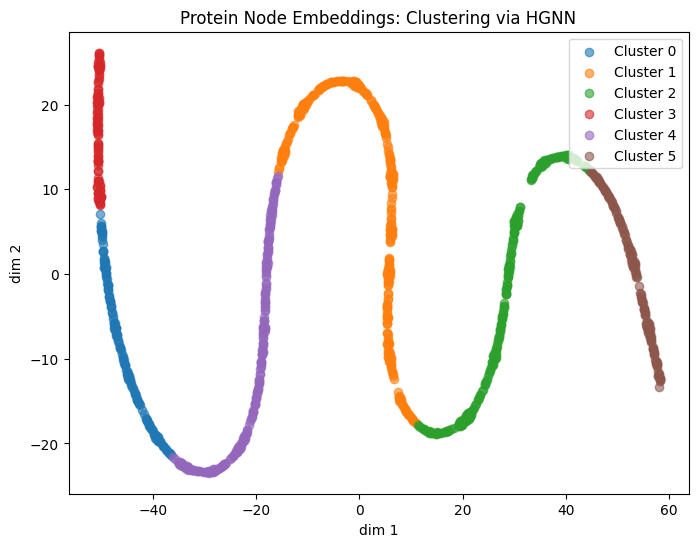

In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

embedded_2d = TSNE(n_components=2, random_state=42).fit_transform(node_embeddings.cpu().numpy())

plt.figure(figsize=(8, 6))
for k in range(n_clusters):
    idx = cluster_labels == k
    plt.scatter(embedded_2d[idx,0], embedded_2d[idx,1], label=f'Cluster {k}', alpha=0.6)
plt.legend()
plt.title("Protein Node Embeddings: Clustering via HGNN")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.show()

In [56]:
#inc_full['source_group']      # e.g., 'Control', 'sPTD', 'PPROM'
#inc_full['source_trimester']  # e.g., 'Second', 'Third'
#inc_full['unique_hyperedge_id']
inc_full


,hyperedge_id,protein_id,source_group,source_trimester,unique_hyperedge_id,protein_idx,hyperedge_idx
0,14-3-3,14-3-3,Control,Second,Control_Second_14-3-3,0,0
1,14-3-3,17-beta-HSD 1,Control,Second,Control_Second_14-3-3,1,0
2,14-3-3,3HIDH,Control,Second,Control_Second_14-3-3,2,0
3,14-3-3,4-1BB,Control,Second,Control_Second_14-3-3,3,0
4,14-3-3,4-1BB ligand,Control,Second,Control_Second_14-3-3,4,0
...,...,...,...,...,...,...,...
2827647,vWF,sE-Selectin,sPTD,Third,sPTD_Third_vWF,1147,6989
2827648,vWF,sICAM-1,sPTD,Third,sPTD_Third_vWF,1149,6989
2827649,vWF,sICAM-2,sPTD,Third,sPTD_Third_vWF,1150,6989
2827650,vWF,tau,sPTD,Third,sPTD_Third_vWF,1161,6989


In [57]:
inc_full[inc_full['unique_hyperedge_id'] == 'Control_Second_Moesin']

,hyperedge_id,protein_id,source_group,source_trimester,unique_hyperedge_id,protein_idx,hyperedge_idx
307127,Moesin,ALT,Control,Second,Control_Second_Moesin,24,745
307128,Moesin,CAMK2A,Control,Second,Control_Second_Moesin,144,745
307129,Moesin,CAMK2B,Control,Second,Control_Second_Moesin,145,745
307130,Moesin,CAMK2D,Control,Second,Control_Second_Moesin,146,745
307131,Moesin,COMMD7,Control,Second,Control_Second_Moesin,199,745
307132,Moesin,Cathepsin G,Control,Second,Control_Second_Moesin,247,745
307133,Moesin,DAPK2,Control,Second,Control_Second_Moesin,282,745
307134,Moesin,EP15R,Control,Second,Control_Second_Moesin,325,745
307135,Moesin,FER,Control,Second,Control_Second_Moesin,374,745
307136,Moesin,FYN,Control,Second,Control_Second_Moesin,405,745


In [19]:
# For each outcome, list hyperedge IDs
outcome_groups = inc_full['source_group'].unique()
for outcome in outcome_groups:
    he_ids = inc_full[inc_full['source_group'] == outcome]['unique_hyperedge_id'].unique()
    print(f"Outcome: {outcome}, N hyperedges: {len(he_ids)}")

Outcome: Control, N hyperedges: 2330
Outcome: PPROM, N hyperedges: 2330
Outcome: sPTD, N hyperedges: 2330


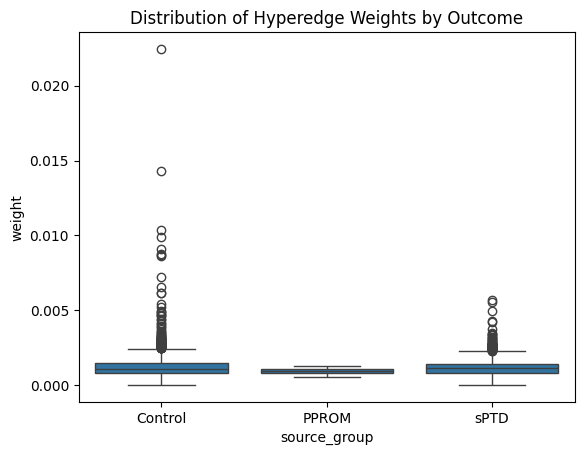

In [20]:
import pandas as pd
# Suppose you have a DataFrame mapping hyperedge_id to outcome and weight:
hyperedge_df = pd.DataFrame({
    'hyperedge_id': hyperedge_ids, 
    'weight': hyperedge_weights.cpu().numpy()
})
# Merge with outcome tags
he_tags = inc_full.drop_duplicates('unique_hyperedge_id')[['unique_hyperedge_id', 'source_group', 'source_trimester']]
hyperedge_df = hyperedge_df.merge(he_tags, left_on='hyperedge_id', right_on='unique_hyperedge_id')

# Boxplot of hyperedge weights across outcomes
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='source_group', y='weight', data=hyperedge_df)
plt.title("Distribution of Hyperedge Weights by Outcome")
plt.show()


In [52]:
#hyperedge_df['weight'].max() #0.022464368
hyperedge_df[hyperedge_df['weight'] == 0.022464368]

,hyperedge_id,weight,unique_hyperedge_id,source_group,source_trimester
745,Control_Second_Moesin,0.022464,Control_Second_Moesin,Control,Second


In [21]:
# For each hyperedge, get member protein indices and their cluster assignments
cluster_assignments = {prot: clu for prot, clu in zip(protein_ids, cluster_labels)}

hyperedge_to_cluster_counts = []
for hid in hyperedge_ids:
    members = inc_full[inc_full['unique_hyperedge_id']==hid]['protein_id'].tolist()
    member_clusters = [cluster_assignments[pid] for pid in members]
    most_common_cluster = max(set(member_clusters), key=member_clusters.count)
    hyperedge_to_cluster_counts.append({
        'hyperedge_id': hid,
        'dominant_cluster': most_common_cluster,
        'n_members': len(members),
        'source_group': he_tags[he_tags['unique_hyperedge_id']==hid]['source_group'].values[0]
    })
he_cluster_df = pd.DataFrame(hyperedge_to_cluster_counts)

In [22]:
he_cluster_df

,hyperedge_id,dominant_cluster,n_members,source_group
0,Control_Second_14-3-3,1,712,Control
1,Control_Second_17-beta-HSD 1,2,543,Control
2,Control_Second_3HIDH,1,440,Control
3,Control_Second_4-1BB,1,669,Control
4,Control_Second_4-1BB ligand,1,485,Control
...,...,...,...,...
6985,sPTD_Third_tPA,4,301,sPTD
6986,sPTD_Third_tau,1,390,sPTD
6987,"sPTD_Third_transcription factor MLR1, isoform ...",2,325,sPTD
6988,sPTD_Third_uPA,1,620,sPTD


In [58]:
he_cluster_df[he_cluster_df['hyperedge_id'] == 'Control_Second_Moesin']

,hyperedge_id,dominant_cluster,n_members,source_group
745,Control_Second_Moesin,5,30,Control


n_clusters = 6
Control:
- Hyperedge Control_Second_Moesin cluster purity: 0.53 -> cluster 5
- Hyperedge Control_Second_SIG14 cluster purity: 0.50 -> cluster 1
- Hyperedge Control_Second_ASAHL cluster purity: 0.43 -> cluster 1
- Hyperedge Control_Second_annexin II cluster purity: 0.40 -> cluster 1
- Hyperedge Control_Third_Moesin cluster purity: 0.33 -> cluster 2

PPROM:
- Hyperedge PPROM_Third_hnRNP K cluster purity: 0.31 -> cluster 1
- Hyperedge PPROM_Third_sICAM-2 cluster purity: 0.31 -> cluster 1
- Hyperedge PPROM_Third_MED-1 cluster purity: 0.31 -> cluster 1
- Hyperedge PPROM_Third_MCP-4 cluster purity: 0.31 -> cluster 1
- Hyperedge PPROM_Third_MCP-1 cluster purity: 0.31 -> cluster 1

sPTD:
- Hyperedge sPTD_Third_ENA-78 cluster purity: 0.35 -> cluster 5
- Hyperedge sPTD_Third_DLC8 cluster purity: 0.33 -> cluster 5
- Hyperedge sPTD_Second_Moesin cluster purity: 0.26 -> cluster 5
- Hyperedge sPTD_Third_b2-Microglobulin cluster purity: 0.32 -> cluster 2
- Hyperedge sPTD_Third_Gelsolin cluster purity: 0.24 -> cluster 5


n_clusters = 3
Control:
- Hyperedge Control_Second_Moesin cluster purity: 0.77 -> cluster 2
- Hyperedge Control_Second_SIG14 cluster purity: 0.50 -> cluster 1
- Hyperedge Control_Second_ASAHL cluster purity: 0.57 -> cluster 1
- Hyperedge Control_Second_annexin II cluster purity: 0.50 -> cluster 1
- Hyperedge Control_Third_Moesin cluster purity: 0.65 -> cluster 2

PPROM:
- Hyperedge PPROM_Third_hnRNP K cluster purity: 0.51 -> cluster 2
- Hyperedge PPROM_Third_sICAM-2 cluster purity: 0.51 -> cluster 2
- Hyperedge PPROM_Third_MED-1 cluster purity: 0.51 -> cluster 2
- Hyperedge PPROM_Third_MCP-4 cluster purity: 0.51 -> cluster 2
- Hyperedge PPROM_Third_MCP-1 cluster purity: 0.51 -> cluster 2

sPTD:
- Hyperedge sPTD_Third_ENA-78 cluster purity: 0.58 -> cluster 2
- Hyperedge sPTD_Third_DLC8 cluster purity: 0.53 -> cluster 2
- Hyperedge sPTD_Second_Moesin cluster purity: 0.50 -> cluster 2
- Hyperedge sPTD_Third_b2-Microglobulin cluster purity: 0.40 -> cluster 1
- Hyperedge sPTD_Third_Gelsolin cluster purity: 0.44 -> cluster 2

# Embedding Space Analysis

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume:
# - hyperedge_weights: torch tensor [num_hyperedges], with distinctiveness/strength per hyperedge
# - hyperedge_ids: list of unique hyperedge IDs (order matches weights)
# - inc_full: DataFrame with columns ['unique_hyperedge_id', 'source_group', 'source_trimester'] and protein membership
# - node_embeddings: [num_nodes, embed_dim] from your trained GNN (as above)
# - cluster_labels: clustering result from your embeddings (see previous steps)
# - protein_ids: node list in order

# Build hyperedge info table
he_info = pd.DataFrame({
    "hyperedge_id": hyperedge_ids,
    "weight": hyperedge_weights.cpu().numpy()
}).merge(
    inc_full.drop_duplicates('unique_hyperedge_id')[['unique_hyperedge_id', 'source_group', 'source_trimester']],
    left_on='hyperedge_id', right_on='unique_hyperedge_id'
)

# For each outcome group, pick top-N hyperedges by weight or distinct feature
top_hyperedges = {}
N = 5  # choose as desired
for group in he_info['source_group'].unique():
    he_sub = he_info[he_info['source_group'] == group]
    top = he_sub.sort_values('weight', ascending=False).head(N)
    top_hyperedges[group] = top['hyperedge_id'].tolist()
    print(f"Top {N} hyperedges for {group}:", top['hyperedge_id'].tolist())


Top 5 hyperedges for Control: ['Control_Second_Moesin', 'Control_Second_SIG14', 'Control_Second_ASAHL', 'Control_Second_annexin II', 'Control_Third_Moesin']
Top 5 hyperedges for PPROM: ['PPROM_Third_hnRNP K', 'PPROM_Third_sICAM-2', 'PPROM_Third_MED-1', 'PPROM_Third_MCP-4', 'PPROM_Third_MCP-1']
Top 5 hyperedges for sPTD: ['sPTD_Third_ENA-78', 'sPTD_Third_DLC8', 'sPTD_Second_Moesin', 'sPTD_Third_b2-Microglobulin', 'sPTD_Third_Gelsolin']


In [25]:
he_to_nodes = {}
for group, he_list in top_hyperedges.items():
    for he in he_list:
        nodes = inc_full[inc_full['unique_hyperedge_id']==he]['protein_id'].tolist()
        he_to_nodes[he] = nodes


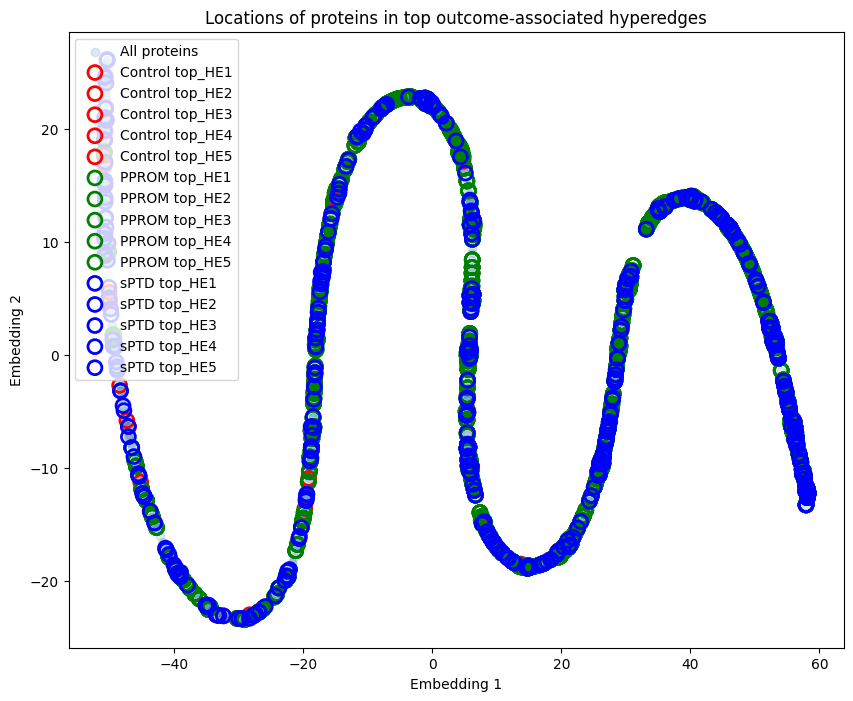

In [26]:
from sklearn.manifold import TSNE

# Reduce embeddings to 2D for visualization
embed_2d = TSNE(n_components=2, random_state=42).fit_transform(node_embeddings.cpu().numpy())

# Make a mapping from protein name to embedding 2D location
prot_to_idx = {p: i for i, p in enumerate(protein_ids)}

plt.figure(figsize=(10,8))
plt.scatter(embed_2d[:,0], embed_2d[:,1], alpha=0.15, label='All proteins')  # background

colors = ['red','green','blue','orange','purple']
for j, (group, he_list) in enumerate(top_hyperedges.items()):
    for i, he in enumerate(he_list):
        nodes = he_to_nodes[he]
        node_idx = [prot_to_idx[n] for n in nodes if n in prot_to_idx]
        plt.scatter(embed_2d[node_idx, 0], embed_2d[node_idx,1], 
                    label=f'{group} top_HE{i+1}', 
                    edgecolor=colors[j % len(colors)], marker='o', facecolors='none', s=100, linewidths=2)

plt.legend()
plt.title("Locations of proteins in top outcome-associated hyperedges")
plt.xlabel("Embedding 1")
plt.ylabel("Embedding 2")
plt.show()


In [27]:
from collections import Counter

def cluster_purity(node_names):
    idxs = [prot_to_idx[n] for n in node_names if n in prot_to_idx]
    clusters = [cluster_labels[i] for i in idxs]
    if not clusters: return np.nan
    counts = Counter(clusters)
    most_common = counts.most_common(1)[0][1]
    return most_common / len(clusters)

for group, he_list in top_hyperedges.items():
    print(f"\n{group}:")
    for he in he_list:
        purity = cluster_purity(he_to_nodes[he])
        print(f"- Hyperedge {he} cluster purity: {purity:.2f}")


Control:
- Hyperedge Control_Second_Moesin cluster purity: 0.53
- Hyperedge Control_Second_SIG14 cluster purity: 0.50
- Hyperedge Control_Second_ASAHL cluster purity: 0.43
- Hyperedge Control_Second_annexin II cluster purity: 0.40
- Hyperedge Control_Third_Moesin cluster purity: 0.33

PPROM:
- Hyperedge PPROM_Third_hnRNP K cluster purity: 0.31
- Hyperedge PPROM_Third_sICAM-2 cluster purity: 0.31
- Hyperedge PPROM_Third_MED-1 cluster purity: 0.31
- Hyperedge PPROM_Third_MCP-4 cluster purity: 0.31
- Hyperedge PPROM_Third_MCP-1 cluster purity: 0.31

sPTD:
- Hyperedge sPTD_Third_ENA-78 cluster purity: 0.35
- Hyperedge sPTD_Third_DLC8 cluster purity: 0.33
- Hyperedge sPTD_Second_Moesin cluster purity: 0.26
- Hyperedge sPTD_Third_b2-Microglobulin cluster purity: 0.32
- Hyperedge sPTD_Third_Gelsolin cluster purity: 0.24
